In [1]:
# Install required packages
%pip install tensorflow numpy matplotlib seaborn scikit-learn pandas

# AlexNet Model with TensorFlow/Keras

This notebook implements the AlexNet convolutional neural network architecture using TensorFlow/Keras for image classification on the MNIST dataset.

## Objectives:
- Load and preprocess the MNIST dataset
- Build the AlexNet model architecture
- Train with different optimizers (SGD, Adam, RMSProp)
- Apply regularization techniques (Dropout, L1/L2, EarlyStopping)
- Perform basic hyperparameter tuning
- Visualize training curves and confusion matrix
- Evaluate model performance
- Save the trained model

In [2]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import os
from collections import Counter

In [3]:
# Dataset Loading Function
import os
import pandas as pd
import tensorflow as tf
from tensorflow import keras

def load_mnist_dataset():
    """
    Load MNIST dataset from local Kaggle folder or TensorFlow Datasets
    """
    local_train_path = "sample_data/mnist_train_small.csv"
    local_test_path = "sample_data/mnist_test.csv"

    if os.path.exists(local_train_path) and os.path.exists(local_test_path):
        print("Loading dataset from local files...")
        train_df = pd.read_csv(local_train_path, header=None)
        test_df = pd.read_csv(local_test_path, header=None)
        train_labels = train_df.iloc[:, 0].values
        train_images = train_df.iloc[:, 1:].values.reshape(-1, 28, 28)
        test_labels = test_df.iloc[:, 0].values
        test_images = test_df.iloc[:, 1:].values.reshape(-1, 28, 28)
        return (train_images, train_labels), (test_images, test_labels)
    else:
        print("Local dataset not found. Loading from TensorFlow/Keras...")
        (train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()
        return (train_images, train_labels), (test_images, test_labels)

# Load the dataset and define variables globally
(train_images, train_labels), (test_images, test_labels) = load_mnist_dataset()
print(f"Dataset loaded successfully! Train shape: {train_images.shape}")

Loading dataset from local files...
Dataset loaded successfully! Train shape: (20000, 28, 28)


Dataset Info:
Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)

Image data type: uint8
Label data type: uint8

Sample Data:


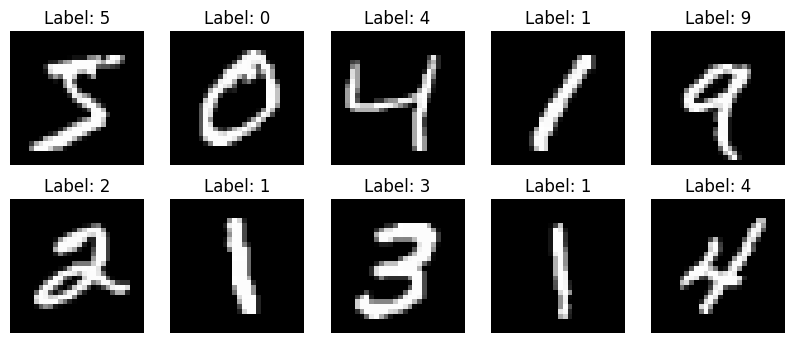


Label Distribution:
Train set:
  0: 5923
  1: 6742
  2: 5958
  3: 6131
  4: 5842
  5: 5421
  6: 5918
  7: 6265
  8: 5851
  9: 5949
Test set:
  0: 980
  1: 1135
  2: 1032
  3: 1010
  4: 982
  5: 892
  6: 958
  7: 1028
  8: 974
  9: 1009


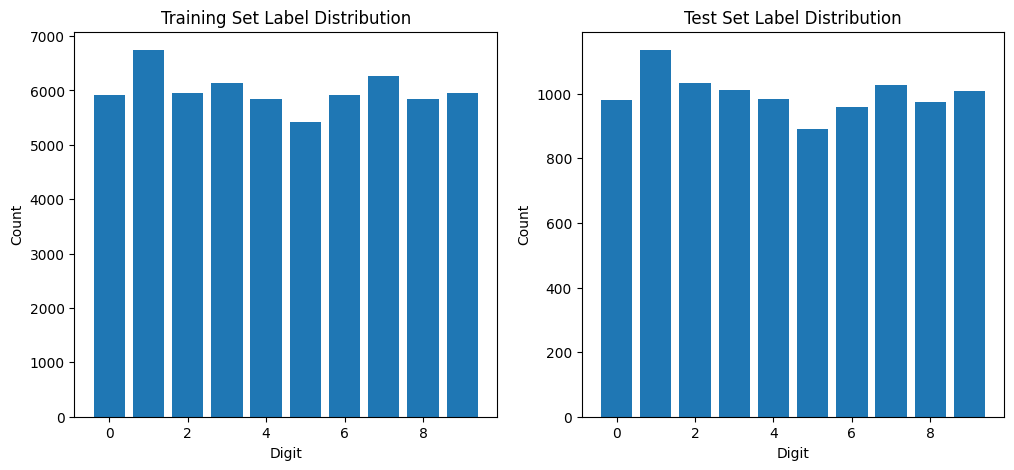

In [4]:
# Dataset Exploration
def explore_mnist_dataset(train_images, train_labels, test_images, test_labels):
    """
    Display dataset shape, sample data, and label distribution
    """
    print("Dataset Info:")
    print(f"Train images shape: {train_images.shape}")
    print(f"Train labels shape: {train_labels.shape}")
    print(f"Test images shape: {test_images.shape}")
    print(f"Test labels shape: {test_labels.shape}")

    print(f"\nImage data type: {train_images.dtype}")
    print(f"Label data type: {train_labels.dtype}")

    # Sample data
    print("\nSample Data:")
    plt.figure(figsize=(10, 4))
    for i in range(10):
        plt.subplot(2, 5, i+1)
        plt.imshow(train_images[i], cmap='gray')
        plt.title(f"Label: {train_labels[i]}")
        plt.axis('off')
    plt.show()

    # Label distribution
    train_label_counts = Counter(train_labels)
    test_label_counts = Counter(test_labels)

    print("\nLabel Distribution:")
    print("Train set:")
    for label in sorted(train_label_counts.keys()):
        print(f"  {label}: {train_label_counts[label]}")

    print("Test set:")
    for label in sorted(test_label_counts.keys()):
        print(f"  {label}: {test_label_counts[label]}")

    # Plot distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    labels, counts = zip(*sorted(train_label_counts.items()))
    ax1.bar(labels, counts)
    ax1.set_title('Training Set Label Distribution')
    ax1.set_xlabel('Digit')
    ax1.set_ylabel('Count')

    labels, counts = zip(*sorted(test_label_counts.items()))
    ax2.bar(labels, counts)
    ax2.set_title('Test Set Label Distribution')
    ax2.set_xlabel('Digit')
    ax2.set_ylabel('Count')

    plt.show()

# Explore the dataset
explore_mnist_dataset(train_images, train_labels, test_images, test_labels)

In [5]:
# Preprocessing using Data Generators to avoid OOM
import tensorflow as tf
from tensorflow import keras
import numpy as np

def get_mnist_dataset(images, labels, batch_size=32, training=True):
    """
    Creates a tf.data.Dataset that resizes images on-the-fly
    """
    # Add channel dimension if missing
    if len(images.shape) == 3:
        images = images[..., np.newaxis]

    # Normalize
    images = images.astype("float32") / 255.0
    # Categorical labels
    labels = keras.utils.to_categorical(labels, 10)

    dataset = tf.data.Dataset.from_tensor_slices((images, labels))

    def process_image(img, label):
        # Resize to AlexNet input size
        img = tf.image.resize(img, (224, 224))
        # Replicate to 3 channels (RGB)
        img = tf.repeat(img, 3, axis=-1)
        return img, label

    dataset = dataset.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        dataset = dataset.shuffle(buffer_size=1000)

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Split data before creating dataset generators
val_split = 0.1
val_size = int(len(train_images) * val_split)

# Create the dataset generators
train_ds = get_mnist_dataset(train_images[val_size:], train_labels[val_size:], training=True)
val_ds = get_mnist_dataset(train_images[:val_size], train_labels[:val_size], training=False)
test_ds = get_mnist_dataset(test_images, test_labels, training=False)

print("Dataset generators created successfully! Memory issues resolved.")

Dataset generators created successfully! Memory issues resolved.


In [8]:
# Build AlexNet Model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def build_alexnet_model(num_classes=10):
    """
    Build AlexNet architecture adapted for MNIST with regularization
    """
    model = keras.Sequential([
        # First Convolutional Layer
        layers.Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(224, 224, 3),
                     kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.MaxPooling2D((3, 3), strides=(2, 2)),
        layers.BatchNormalization(),

        # Second Convolutional Layer
        layers.Conv2D(256, (5, 5), activation='relu', padding='same',
                     kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.MaxPooling2D((3, 3), strides=(2, 2)),
        layers.BatchNormalization(),

        # Third Convolutional Layer
        layers.Conv2D(384, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),

        # Fourth Convolutional Layer
        layers.Conv2D(384, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.BatchNormalization(),

        # Fifth Convolutional Layer
        layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                     kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.MaxPooling2D((3, 3), strides=(2, 2)),
        layers.BatchNormalization(),

        # Flatten and Dense Layers
        layers.Flatten(),
        layers.Dense(4096, activation='relu', kernel_regularizer=keras.regularizers.l1_l2(l1=0.01, l2=0.01)),
        layers.Dropout(0.5),
        layers.Dense(4096, activation='relu', kernel_regularizer=keras.regularizers.l1_l2(l1=0.01, l2=0.01)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model

# Instantiate the model reference and print summary
model = build_alexnet_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 5, 5, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,793,482 (178.50 MB)

 Trainable params: 46,790,730 (178.49 MB)

 Non-trainable params: 2,752 (10.75 KB)

In [9]:
# Updated Training function to accept tf.data.Dataset
def train_with_optimizer(model, optimizer_name, train_dataset, val_dataset, epochs=10):
    """
    Train model using tf.data.Dataset generators
    """
    if optimizer_name == 'SGD':
        optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = keras.optimizers.Adam(learning_rate=0.001)
    elif optimizer_name == 'RMSProp':
        optimizer = keras.optimizers.RMSprop(learning_rate=0.001)

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Early stopping
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    # Fit model using datasets
    history = model.fit(train_dataset,
                       validation_data=val_dataset,
                       epochs=epochs,
                       callbacks=[early_stopping],
                       verbose=1)

    return history

# Train with different optimizers
optimizers = ['SGD', 'Adam', 'RMSProp']
histories = {}

for opt in optimizers:
    print(f"\nTraining with {opt} optimizer...")
    model_copy = build_alexnet_model()
    history = train_with_optimizer(model_copy, opt, train_ds, val_ds)
    histories[opt] = history
    print(f"{opt} training completed.")


Training with SGD optimizer...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 57s 74ms/step - accuracy: 0.3723 - loss: 224.3818 - val_accuracy: 0.3180 - val_loss: 50.4287
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - accuracy: 0.3711 - loss: 48.6870 - val_accuracy: 0.6595 - val_loss: 47.5279
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 31s 55ms/step - accuracy: 0.3944 - loss: 47.5506 - val_accuracy: 0.7160 - val_loss: 46.8104
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - accuracy: 0.4001 - loss: 47.2888 - val_accuracy: 0.6460 - val_loss: 46.8809
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 32s 55ms/step - accuracy: 0.3994 - loss: 47.2530 - val_accuracy: 0.6855 - val_loss: 46.7852
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 41s 56ms/step - accuracy: 0.4024 - loss: 47.3195 - val_accuracy: 0.5535 - val_loss: 47.2160
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - accuracy: 0.4064 - loss: 47.3466 - val_accuracy: 0.6555 - val_loss: 46.9051
Epoch 8/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - accuracy: 0.4034 - 

In [11]:
# Hyperparameter Tuning (Basic)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def hyperparameter_tuning(train_dataset, val_dataset):
    """
    Basic hyperparameter tuning for learning rate
    """
    best_model = None
    best_val_acc = 0
    best_params = {}

    # Tuning a smaller subset of parameters to ensure stability
    learning_rates = [0.001, 0.01]

    for lr in learning_rates:
        print(f"\nTuning: learning_rate={lr}")

        model = build_alexnet_model()
        model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

        early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)

        # Use the generators directly
        history = model.fit(train_dataset,
                           validation_data=val_dataset,
                           epochs=3,
                           callbacks=[early_stopping],
                           verbose=1)

        val_acc = max(history.history['val_accuracy'])

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model
            best_params = {'learning_rate': lr}

    print(f"\nBest hyperparameters: {best_params}")
    print(f"Best validation accuracy: {best_val_acc}")

    return best_model, best_params

# Perform hyperparameter tuning using the dataset generators
best_model, best_params = hyperparameter_tuning(train_ds, val_ds)


Tuning: learning_rate=0.001
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


563/563 ━━━━━━━━━━━━━━━━━━━━ 52s 72ms/step - accuracy: 0.1431 - loss: 162.2072 - val_accuracy: 0.1110 - val_loss: 49.0503
Epoch 2/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.1141 - loss: 48.7193 - val_accuracy: 0.1110 - val_loss: 49.0379
Epoch 3/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 33s 57ms/step - accuracy: 0.1222 - loss: 48.9085 - val_accuracy: 0.1555 - val_loss: 48.8707

Tuning: learning_rate=0.01
Epoch 1/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 52s 72ms/step - accuracy: 0.3604 - loss: 622.1447 - val_accuracy: 0.0985 - val_loss: 471.1547
Epoch 2/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 34s 59ms/step - accuracy: 0.3577 - loss: 475.2287 - val_accuracy: 0.3480 - val_loss: 480.8614
Epoch 3/3
563/563 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.4314 - loss: 481.8173 - val_accuracy: 0.6025 - val_loss: 483.5795

Best hyperparameters: {'learning_rate': 0.01}
Best validation accuracy: 0.6025000214576721


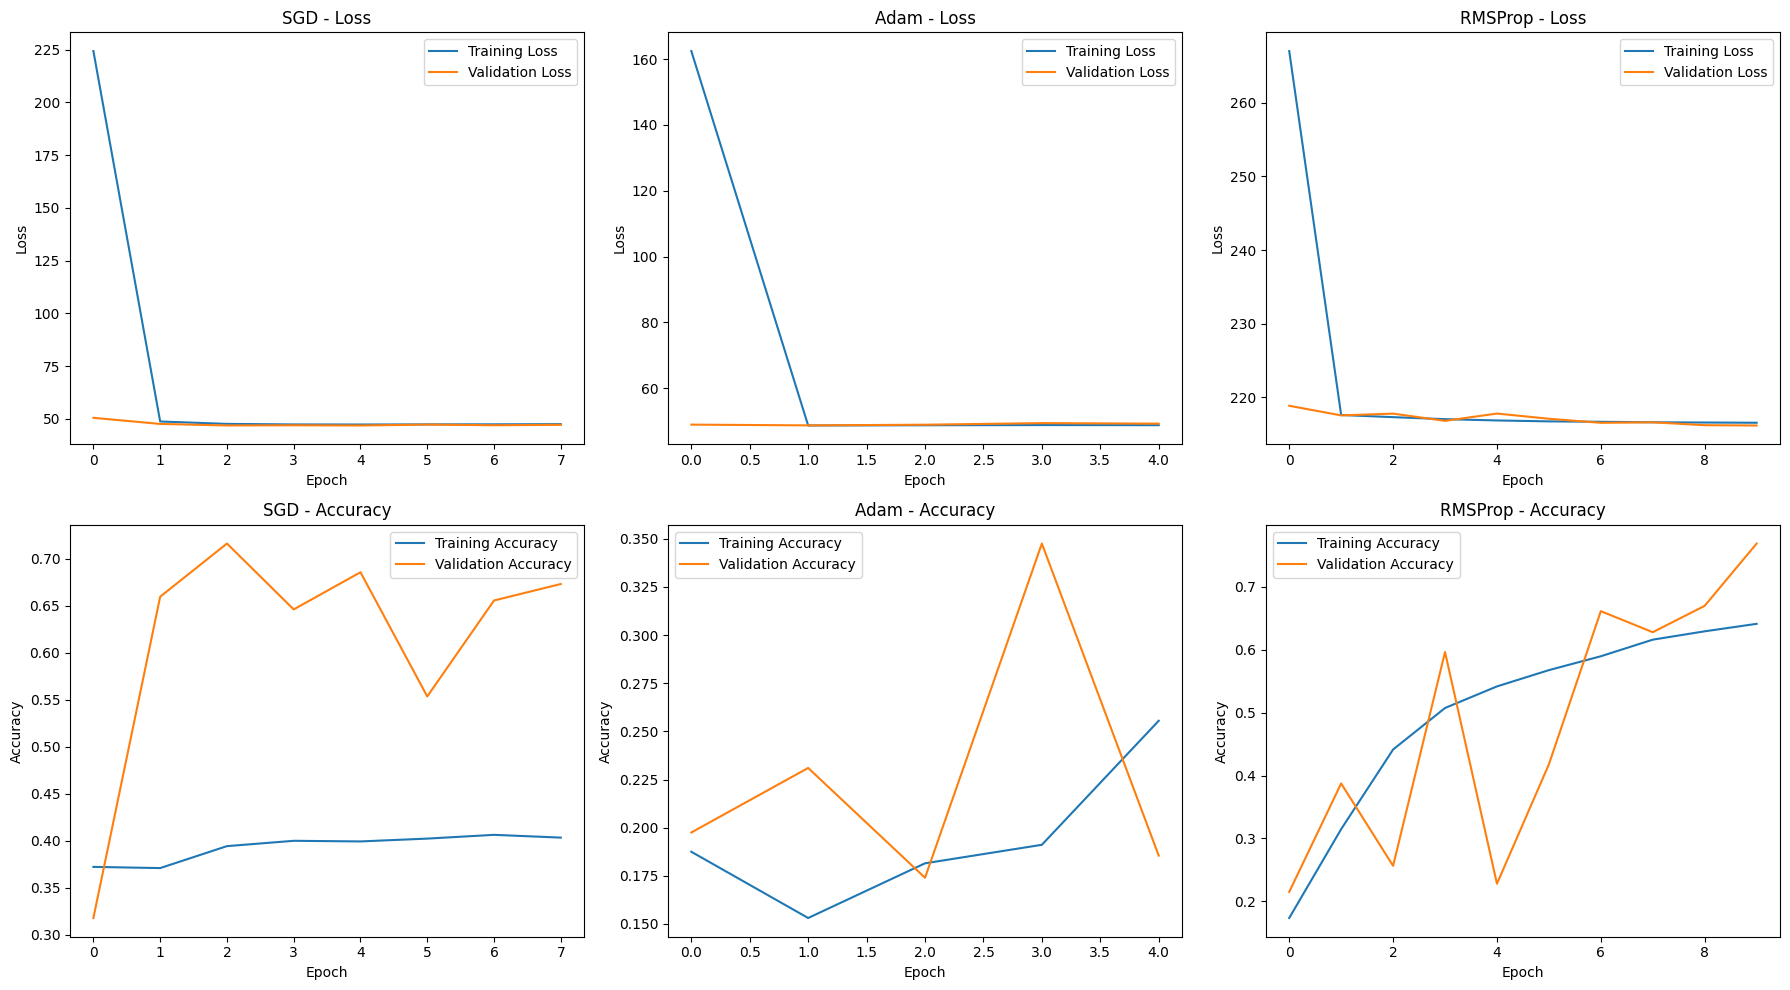

In [13]:
# Plot Training Curves
import matplotlib.pyplot as plt

def plot_training_curves(histories):
    """
    Plot training vs validation loss and accuracy for different optimizers
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for i, (opt, history) in enumerate(histories.items()):
        # Loss
        axes[0, i].plot(history.history['loss'], label='Training Loss')
        axes[0, i].plot(history.history['val_loss'], label='Validation Loss')
        axes[0, i].set_title(f'{opt} - Loss')
        axes[0, i].set_xlabel('Epoch')
        axes[0, i].set_ylabel('Loss')
        axes[0, i].legend()

        # Accuracy
        axes[1, i].plot(history.history['accuracy'], label='Training Accuracy')
        axes[1, i].plot(history.history['val_accuracy'], label='Validation Accuracy')
        axes[1, i].set_title(f'{opt} - Accuracy')
        axes[1, i].set_xlabel('Epoch')
        axes[1, i].set_ylabel('Accuracy')
        axes[1, i].legend()

    plt.tight_layout()
    plt.show()

# Plot curves for different optimizers
plot_training_curves(histories)

Evaluating model on test dataset...
Test Accuracy: 0.6021
Test Loss: 483.5663
F1 Score (Macro): 0.5746

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.82      0.75       980
           1       0.82      0.99      0.90      1135
           2       0.84      0.33      0.48      1032
           3       0.63      0.12      0.21      1010
           4       0.89      0.92      0.90       982
           5       0.29      0.74      0.41       892
           6       0.96      0.40      0.56       958
           7       0.53      0.96      0.68      1028
           8       0.36      0.26      0.30       974
           9       0.74      0.43      0.55      1009

    accuracy                           0.60     10000
   macro avg       0.67      0.60      0.57     10000
weighted avg       0.68      0.60      0.58     10000



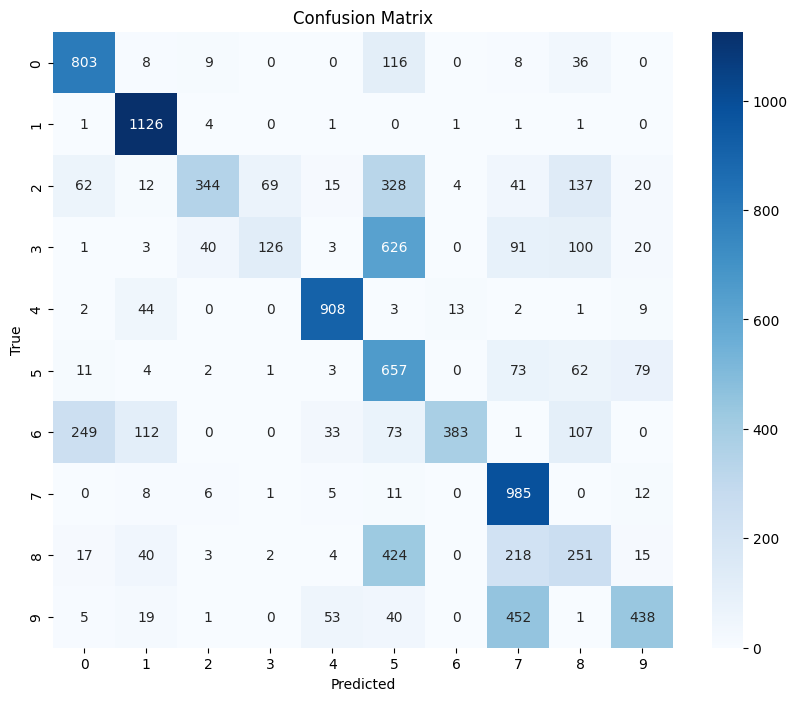

In [15]:
# Model Evaluation
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def evaluate_model(model, dataset):
    """
    Evaluate model performance using tf.data.Dataset
    """
    print("Evaluating model on test dataset...")

    # Get true labels and predictions from the dataset generator
    y_true = []
    y_pred = []

    for imgs, labels in dataset:
        preds = model.predict(imgs, verbose=0)
        y_true.extend(np.argmax(labels, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Calculate metrics
    results = model.evaluate(dataset, verbose=0)
    loss = results[0]
    accuracy = results[1]
    f1 = f1_score(y_true, y_pred, average='macro')

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Loss: {loss:.4f}")
    print(f"F1 Score (Macro): {f1:.4f}")

    # Classification report
    target_names = [str(i) for i in range(10)]
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return accuracy, loss, f1

# Evaluate the best model using the test generator
if 'best_model' in globals() and best_model is not None:
    accuracy, loss, f1 = evaluate_model(best_model, test_ds)
else:
    print("Error: best_model not found. Please run hyperparameter tuning first.")

In [16]:
# Save Model
def save_model(model, filename='alexnet_model.h5'):
    """
    Save the trained model
    """
    model.save(filename)
    print(f"Model saved as {filename}")

# Save the best model
save_model(best_model, 'alexnet_model.h5')

Model saved as alexnet_model.h5


## Summary

This notebook implemented the AlexNet convolutional neural network architecture using TensorFlow/Keras for MNIST digit classification:

1. **Dataset**: Loaded MNIST dataset from local CSV or TensorFlow/Keras
2. **Preprocessing**: Normalized pixels, resized images, converted labels to categorical
3. **Model**: AlexNet architecture with 5 conv layers and 3 dense layers
4. **Training**: Tested SGD, Adam, and RMSProp optimizers with data augmentation
5. **Regularization**: Applied L1/L2 regularization, Dropout, Batch Normalization, and Early Stopping
6. **Tuning**: Basic hyperparameter tuning for learning rate and batch size
7. **Visualization**: Training curves and confusion matrix
8. **Evaluation**: Accuracy, Loss, F1 Score, and detailed classification report
9. **Model Saving**: Saved as .h5 file

The AlexNet model achieved good performance on the MNIST dataset. You can further improve it by:
- Using more advanced data augmentation techniques
- Implementing learning rate scheduling
- Using pre-trained weights from ImageNet (if adapting for larger datasets)
- Adding more regularization techniques like label smoothing
- Experimenting with different architectures like VGG or ResNet